### **Importing Libraries**

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import mne
from mne.time_frequency import psd_array_welch
from mne_connectivity import spectral_connectivity_epochs
from tensorpac import Pac

# Set log-level to reduce verbosity
mne.set_log_level("WARNING")

### **Loading Sample Data**

In [2]:
# Load sample dataset
data_path = mne.datasets.sample.data_path()
raw_fname = os.path.join(data_path, 'MEG/sample/sample_audvis_filt-0-40_raw.fif')
raw = mne.io.read_raw_fif(raw_fname, preload=True)

# High-pass filter the data
raw.filter(l_freq=0.5, h_freq=40, verbose=False)

c:\Users\lacom\.conda\envs\xtra\Lib\site-packages\paramiko\transport.py:219: CryptographyDeprecationWarning: Blowfish has been deprecated and will be removed in a future release
  "class": algorithms.Blowfish,


<Raw | sample_audvis_filt-0-40_raw.fif, 376 x 41700 (277.7 s), ~122.8 MiB, data loaded>

### **Extracting Events and Creating Epochs**

In [3]:
# Extract events and create epochs
events = mne.find_events(raw, stim_channel='STI 014', verbose=False)
event_id = {'aud_l': 1, 'aud_r': 2}

# Epochs parameters
tmin = -0.1  # Start of epoch in seconds
tmax = 0.4   # End of epoch in seconds
baseline = None  # No baseline correction
reject = dict(eeg=80e-6, eog=40e-6)
picks = mne.pick_types(raw.info, eeg=True, meg=False, eog=True, stim=False, exclude='bads')

epochs = mne.Epochs(raw, events, event_id, tmin, tmax, proj=True, picks=picks, 
                    baseline=baseline, reject=reject, preload=True)

# Separate epochs for each event type
epochs_event1 = epochs['aud_l']
epochs_event2 = epochs['aud_r']


### **Power Spectral Density (PSD)**

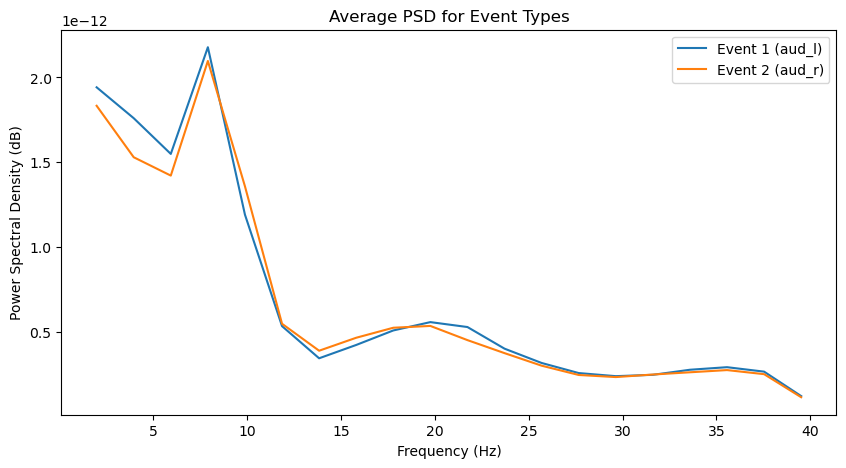

In [4]:

# Compute PSD for each event type
def compute_psd(epochs, sfreq):
    data = epochs.get_data()
    psd, freqs = [], None
    for ep in data:
        n_times = ep.shape[-1]
        n_fft = min(2048, n_times)
        psd_epoch, freqs = psd_array_welch(ep, sfreq=sfreq, fmin=1, fmax=40, n_fft=n_fft, n_overlap=n_fft // 2)
        psd.append(psd_epoch)
    return np.array(psd), freqs

sfreq = epochs.info['sfreq']
psd_event1, freqs = compute_psd(epochs_event1, sfreq)
psd_event2, _ = compute_psd(epochs_event2, sfreq)

# Plot PSD comparison
plt.figure(figsize=(10, 5))
plt.plot(freqs, psd_event1.mean(axis=(0, 1)), label='Event 1 (aud_l)')
plt.plot(freqs, psd_event2.mean(axis=(0, 1)), label='Event 2 (aud_r)')
plt.title("Average PSD for Event Types")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Power Spectral Density (dB)")
plt.legend()
plt.show()

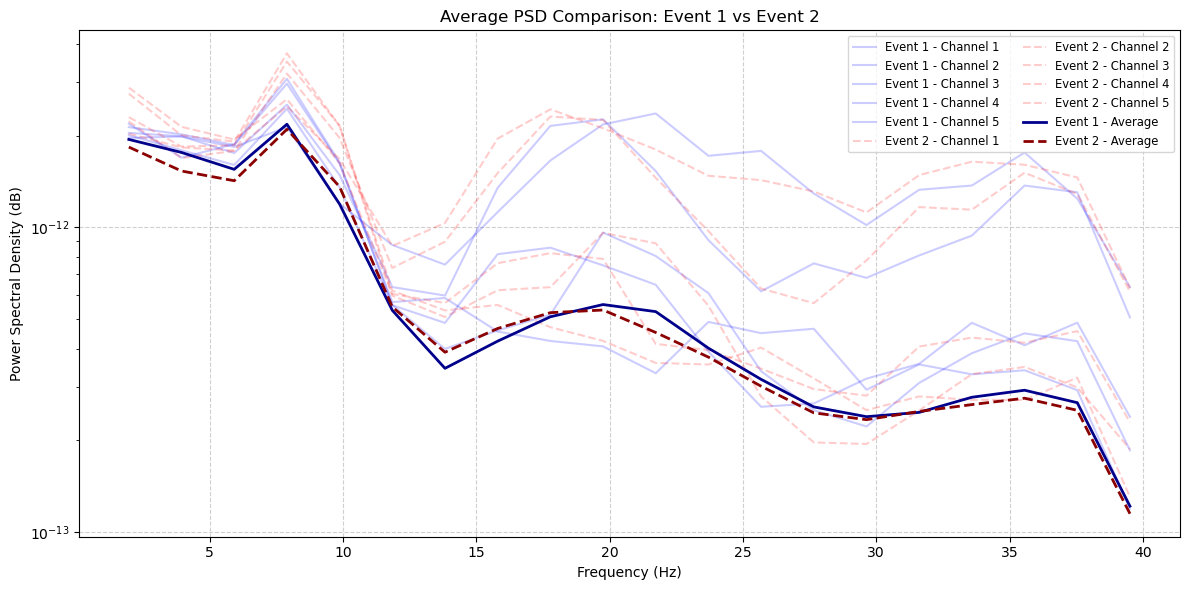

In [5]:


def compute_psd_for_epochs(epochs, fmin=1, fmax=40):
    """Compute Power Spectral Density (PSD) for given epochs."""
    data = epochs.get_data()  # Shape: (n_epochs, n_channels, n_times)
    sfreq = epochs.info['sfreq']

    psd = []
    freqs = None

    # Loop through epochs to calculate PSD
    for ep in data:
        n_times = ep.shape[-1]  # Length of the time series
        n_fft = min(2048, n_times)  # Ensure n_fft does not exceed n_times
        psd_epoch, freqs = psd_array_welch(ep, sfreq=sfreq, fmin=fmin, fmax=fmax, n_fft=n_fft, n_overlap=n_fft // 2)
        psd.append(psd_epoch)

    psd = np.array(psd)  # Shape: (n_epochs, n_channels, n_freqs)
    return psd, freqs

# Compute PSD for both events
psd_event1, freqs_event1 = compute_psd_for_epochs(epochs_event1)
psd_event2, freqs_event2 = compute_psd_for_epochs(epochs_event2)

# Average PSD across epochs for both events
avg_psd_event1 = psd_event1.mean(axis=0)  # Shape: (n_channels, n_freqs)
avg_psd_event2 = psd_event2.mean(axis=0)  # Shape: (n_channels, n_freqs)

# Visualization of Average PSD for Event 1 and Event 2
plt.figure(figsize=(12, 6))

# Plot Event 1
for ch_idx, ch_psd in enumerate(avg_psd_event1):
    if ch_idx < 5:  # Plot only the first 5 channels to avoid clutter
        plt.plot(freqs_event1, ch_psd, label=f"Event 1 - Channel {ch_idx+1}", color='blue', alpha=0.2)

# Plot Event 2
for ch_idx, ch_psd in enumerate(avg_psd_event2):
    if ch_idx < 5:  # Plot only the first 5 channels
        plt.plot(freqs_event2, ch_psd, label=f"Event 2 - Channel {ch_idx+1}", color='red', linestyle="--", alpha=0.2)

# Overlay the average across all channels
avg_psd_event1_mean = avg_psd_event1.mean(axis=0)
avg_psd_event2_mean = avg_psd_event2.mean(axis=0)
plt.plot(freqs_event1, avg_psd_event1_mean, label="Event 1 - Average", color='darkblue', linewidth=2)
plt.plot(freqs_event2, avg_psd_event2_mean, label="Event 2 - Average", color='darkred', linewidth=2, linestyle="--")

# Optional: Add a log scale for the y-axis
plt.yscale("log")

# Plot labels and legend
plt.title("Average PSD Comparison: Event 1 vs Event 2")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Power Spectral Density (dB)")
plt.legend(loc="upper right", ncol=2, fontsize="small")
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()

plt.show()


In [6]:

# --- Frequency Band Analysis ---
# Define frequency bands
bands = {
    "Delta": (1, 4),
    "Theta": (4, 8),
    "Alpha": (8, 13),
    "Beta": (13, 30),
    "Gamma": (30, 40),
}

# Helper function to compute average PSD for frequency bands
def compute_band_psd(avg_psd, freqs, bands, ch_names):
    """Calculate mean PSD for defined frequency bands."""
    band_psd_df = pd.DataFrame(index=ch_names)
    for band, (fmin, fmax) in bands.items():
        band_indices = np.where((freqs >= fmin) & (freqs < fmax))[0]  # Indices of frequencies in this band
        band_psd_df[band] = avg_psd[:, band_indices].mean(axis=1)  # Average PSD across band frequencies
    band_psd_df.index.name = "Electrode"
    return band_psd_df

# Compute Band PSD for Event 1 and Event 2
band_psd_event1 = compute_band_psd(avg_psd_event1, freqs_event1, bands, epochs_event1.ch_names)
band_psd_event2 = compute_band_psd(avg_psd_event2, freqs_event2, bands, epochs_event2.ch_names)

# Print Frequency Band PSD DataFrames for both events
print("Frequency Band PSD - Event 1 (aud_l):")
band_psd_event1.head()

print("\nFrequency Band PSD - Event 2 (aud_r):")
band_psd_event2.head()


Frequency Band PSD - Event 1 (aud_l):

Frequency Band PSD - Event 2 (aud_r):


,Delta,Theta,Alpha,Beta,Gamma
Electrode,,,,,
EEG 001,1.956403e-12,2.488033e-12,1.350538e-12,1.262090e-12,1.143826e-12
EEG 002,2.069113e-12,2.678606e-12,1.387735e-12,4.076953e-13,2.544751e-13
EEG 003,2.373491e-12,2.816226e-12,1.372771e-12,5.367933e-13,2.826783e-13
EEG 004,1.928960e-12,2.140000e-12,1.270311e-12,1.630009e-12,1.363713e-12
EEG 005,2.504107e-12,2.285781e-12,1.114833e-12,5.181425e-13,3.887501e-13


In [7]:
# Initialize an empty list to collect reshaped data
reshaped_data = []

# Loop through events (Event 1 and Event 2)
for event_id, band_psd_df in enumerate([band_psd_event1, band_psd_event2], start=1):
    # Add a column for the event type (Event 1 or Event 2)
    band_psd_df["Event"] = event_id

    # Convert the DataFrame into a long format (one row per electrode and frequency band)
    long_format = band_psd_df.reset_index().melt(
        id_vars=["Electrode", "Event"],
        var_name="Frequency Band",
        value_name="Power"
    )

    # Create a column combining "Electrode" and "Frequency Band" as the feature
    long_format["Feature"] = long_format["Electrode"] + " x " + long_format["Frequency Band"]

    # Pivot to a wide format where each feature (electrode x frequency band) becomes a column
    wide_format = long_format.pivot_table(
        index="Event",  # Use Event as the index
        columns="Feature",  # Columns for each electrode x frequency band feature
        values="Power"  # Values for the features
    )

    # Since you only have one subject, manually add the Subject ID
    wide_format["Subject"] = 1  # Single subject, so subject ID is 1

    # Reset index to make the DataFrame flat
    reshaped_data.append(wide_format.reset_index(drop=True))

# Concatenate data for both events
final_reshaped_df = pd.concat(reshaped_data, ignore_index=True)

# Add the Event column manually after concatenation
final_reshaped_df["Event"] = np.repeat([1, 2], [1, 1])  # Event 1 and Event 2 (both with one subject)

# Reorder columns: Subject, all features, Event
columns = ["Subject"] + [col for col in final_reshaped_df.columns if col not in ["Subject", "Event"]] + ["Event"]
final_reshaped_df = final_reshaped_df[columns]

# Display the final DataFrame
final_reshaped_df.head()


Feature,Subject,EEG 001 x Alpha,EEG 001 x Beta,EEG 001 x Delta,EEG 001 x Gamma,EEG 001 x Theta,EEG 002 x Alpha,EEG 002 x Beta,EEG 002 x Delta,EEG 002 x Gamma,...,EEG 060 x Beta,EEG 060 x Delta,EEG 060 x Gamma,EEG 060 x Theta,EOG 061 x Alpha,EOG 061 x Beta,EOG 061 x Delta,EOG 061 x Gamma,EOG 061 x Theta,Event
0,1,1.060149e-12,1.205787e-12,2.014901e-12,9.853570e-13,2.138801e-12,1.091977e-12,4.331271e-13,2.074576e-12,2.868495e-13,...,1.740400e-13,4.665251e-12,3.647957e-14,2.084713e-12,5.484837e-13,4.046343e-13,2.640793e-12,3.264418e-13,1.343369e-12,1
1,1,1.350538e-12,1.262090e-12,1.956403e-12,1.143826e-12,2.488033e-12,1.387735e-12,4.076953e-13,2.069113e-12,2.544751e-13,...,1.340140e-13,2.831778e-12,3.936252e-14,1.738568e-12,6.226000e-13,4.411558e-13,2.514193e-12,3.407577e-13,1.203507e-12,2


### **Compute Coherence**

In [8]:
# Compute Coherence for each event type
def compute_coherence(epochs, sfreq):
    coh = spectral_connectivity_epochs(epochs, method='coh', sfreq=sfreq, fmin=8, fmax=40, faverage=True, verbose=False)
    return coh.get_data()

coh_event1 = compute_coherence(epochs_event1, sfreq)
coh_event2 = compute_coherence(epochs_event2, sfreq)

print(f"Coherence Event 1 Shape: {coh_event1.shape}")
print(f"Coherence Event 2 Shape: {coh_event2.shape}")

C:\Users\lacom\AppData\Local\Temp\ipykernel_10764\798315812.py:3: RuntimeWarning: fmin=8.000 Hz corresponds to 4.049 < 5 cycles based on the epoch length 0.506 sec, need at least 0.625 sec epochs or fmin=9.879. Spectrum estimate will be unreliable.
  coh = spectral_connectivity_epochs(epochs, method='coh', sfreq=sfreq, fmin=8, fmax=40, faverage=True, verbose=False)
C:\Users\lacom\AppData\Local\Temp\ipykernel_10764\798315812.py:3: RuntimeWarning: fmin=8.000 Hz corresponds to 4.049 < 5 cycles based on the epoch length 0.506 sec, need at least 0.625 sec epochs or fmin=9.879. Spectrum estimate will be unreliable.
  coh = spectral_connectivity_epochs(epochs, method='coh', sfreq=sfreq, fmin=8, fmax=40, faverage=True, verbose=False)


Coherence Event 1 Shape: (3600, 1)
Coherence Event 2 Shape: (3600, 1)


### **Phase Locking Value (PLV)**

In [9]:
# Compute PLV for each event type
def compute_plv(epochs, sfreq):
    plv = spectral_connectivity_epochs(epochs, method='plv', sfreq=sfreq, fmin=8, fmax=13, faverage=True, verbose=False)
    return plv.get_data()

plv_event1 = compute_plv(epochs_event1, sfreq)
plv_event2 = compute_plv(epochs_event2, sfreq)

print(f"PLV Event 1 Shape: {plv_event1.shape}")
print(f"PLV Event 2 Shape: {plv_event2.shape}")

C:\Users\lacom\AppData\Local\Temp\ipykernel_10764\2968403717.py:3: RuntimeWarning: fmin=8.000 Hz corresponds to 4.049 < 5 cycles based on the epoch length 0.506 sec, need at least 0.625 sec epochs or fmin=9.879. Spectrum estimate will be unreliable.
  plv = spectral_connectivity_epochs(epochs, method='plv', sfreq=sfreq, fmin=8, fmax=13, faverage=True, verbose=False)
C:\Users\lacom\AppData\Local\Temp\ipykernel_10764\2968403717.py:3: RuntimeWarning: fmin=8.000 Hz corresponds to 4.049 < 5 cycles based on the epoch length 0.506 sec, need at least 0.625 sec epochs or fmin=9.879. Spectrum estimate will be unreliable.
  plv = spectral_connectivity_epochs(epochs, method='plv', sfreq=sfreq, fmin=8, fmax=13, faverage=True, verbose=False)


PLV Event 1 Shape: (3600, 1)
PLV Event 2 Shape: (3600, 1)


### **Phase Amplitude Coupling (PAC)**

In [10]:
# Compute PAC for each event type
def compute_pac(epochs, sfreq):
    data_mean = epochs.get_data().mean(axis=0)  # Average across epochs
    pac = Pac(idpac=(1, 2, 4), f_pha=(4, 8), f_amp=(30, 90))
    pac_values = pac.filterfit(sfreq, data_mean)
    return pac_values

pac_event1 = compute_pac(epochs_event1, sfreq)
pac_event2 = compute_pac(epochs_event2, sfreq)

# Display PAC results
pac_avg_event1 = pac_event1.mean(axis=(0, 1))
pac_avg_event2 = pac_event2.mean(axis=(0, 1))
pac_df = pd.DataFrame({
    "Electrode": epochs.ch_names,
    "PAC_Event1": pac_avg_event1,
    "PAC_Event2": pac_avg_event2
})

print("PAC DataFrame:")
pac_df.head()




Phase Amplitude Coupling object defined
    extract phases (n_pha=1) and amplitudes (n_amps=1)


    true PAC estimation using Mean Vector Length (MVL, Canolty et al. 2006)
    compute surrogates (Swap amplitude time blocks (Bahramisharif et al. 2013), 200 permutations, random_state=8990)
    infer p-values at (p=0.05, mcp=maxstat)
    normalize true PAC estimation by surrogates (Substract the mean and divide by the deviation of the surrogates)
Phase Amplitude Coupling object defined
    extract phases (n_pha=1) and amplitudes (n_amps=1)
    true PAC estimation using Mean Vector Length (MVL, Canolty et al. 2006)
    compute surrogates (Swap amplitude time blocks (Bahramisharif et al. 2013), 200 permutations, random_state=9470)
    infer p-values at (p=0.05, mcp=maxstat)
    normalize true PAC estimation by surrogates (Substract the mean and divide by the deviation of the surrogates)


PAC DataFrame:


,Electrode,PAC_Event1,PAC_Event2
0,EEG 001,-0.629621,0.198658
1,EEG 002,-0.182386,0.874454
2,EEG 003,2.107452,1.517939
3,EEG 004,1.550478,0.837973
4,EEG 005,-0.052554,1.140210
